In [10]:
import os
import re

In [11]:
TRAIN_DIR = "dl-lab-2-stuff-detection/yolo_dataset/yolo_dataset/train"
IMAGES_DIR = f"{TRAIN_DIR}/images"
LABELS_DIR = f"{TRAIN_DIR}/labels"
WORK_DIR = "annotated_images"

In [12]:
names = os.listdir(WORK_DIR)
print(f"{len(names)=}")
names[:5]

len(names)=3908


['0209-20_00866800.jpg',
 '0209-12_00868200.jpg',
 '0209-2_00867800.jpg',
 '0209-35_00889700.jpg',
 '0209-21_00879900.jpg']

In [13]:
gs = [[], [], [], []]

for name in names:
    split = re.split(r'[-_.]', name)
    assert len(split) == 4
    for i, g in enumerate(split):
        gs[i].append(g)

fmt = `0209-<loc>_<id>.jpg`

In [ ]:
set(map(int, list(set(gs[1]))))

In [30]:
set(range(36)) ^ set(map(int, list(set(gs[1]))))

{0, 1, 4, 9, 32}

Loc    | Кадров  | Мин ID     | Макс ID    | Макс пропуск (сек)
------------------------------------------------------------
2      | 130     | 864200     | 887700     | 108.0          
3      | 130     | 866600     | 975500     | 308.0          
5      | 111     | 870000     | 1730600    | 8560.0         
6      | 130     | 864000     | 890100     | 120.0          
7      | 130     | 868100     | 1174900    | 788.0          
8      | 130     | 864000     | 910500     | 104.0          
10     | 130     | 864300     | 1019400    | 352.0          
11     | 130     | 867800     | 1083000    | 580.0          
12     | 130     | 864000     | 881100     | 40.0           
13     | 130     | 874200     | 1004400    | 1240.0         
14     | 130     | 864000     | 886300     | 32.0           
15     | 130     | 864300     | 921600     | 96.0           
16     | 130     | 869400     | 1240200    | 1828.0         
17     | 130     | 864100     | 895000     | 100.0          
18     | 130     | 86

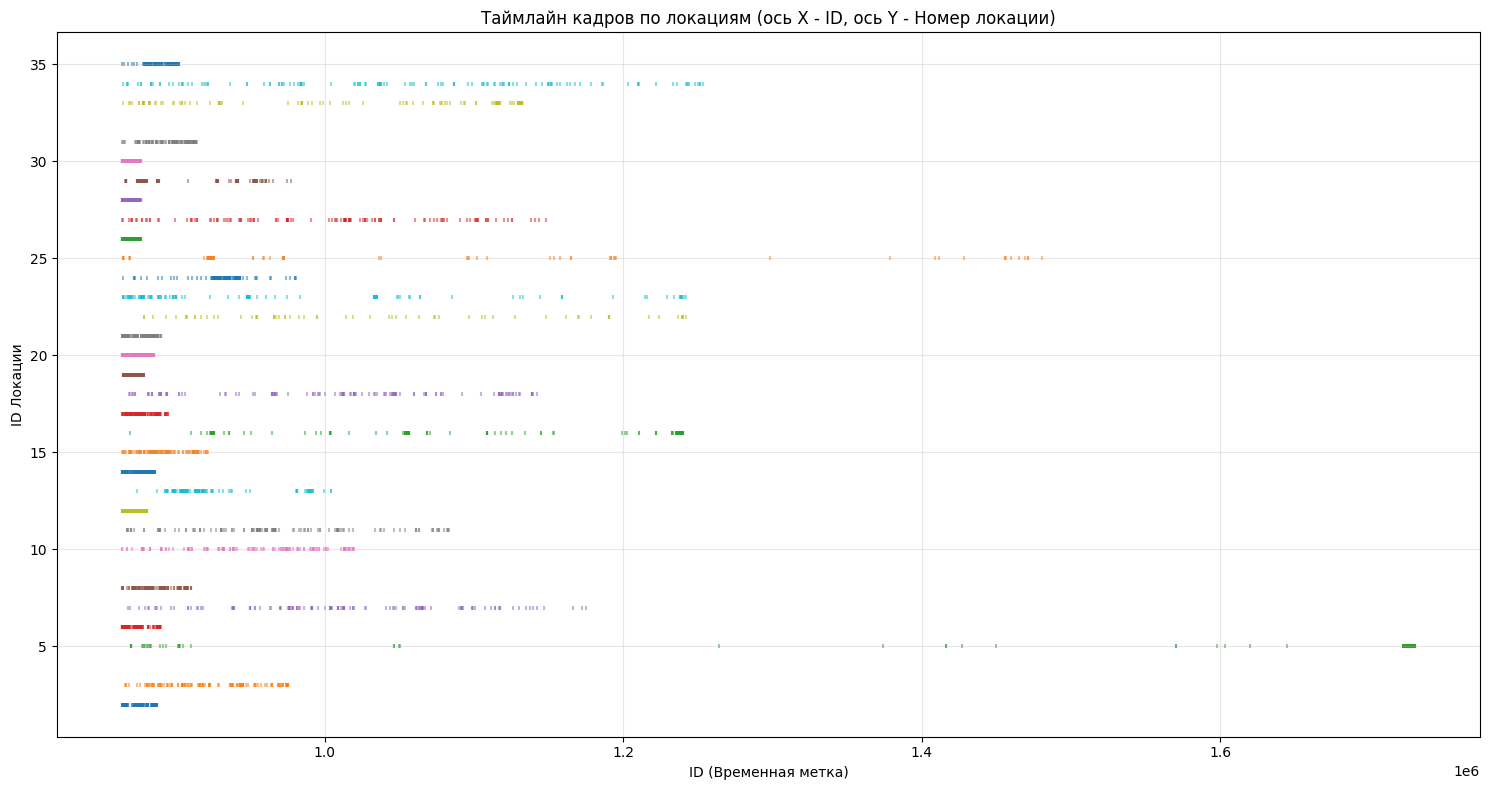

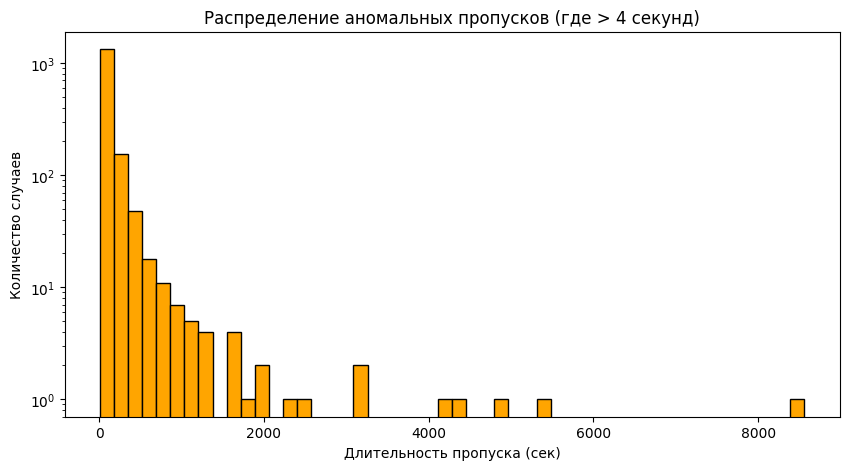

In [ ]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict

SOURCE_DIR = "annotated_images" 

data = defaultdict(list)

files = [f for f in os.listdir(SOURCE_DIR) if f.endswith('.jpg')]

for filename in files:
    try:
        # Парсим: 0209-15_00871234.jpg
        parts = filename.split('-')
        loc = parts[1].split('_')[0]
        # Извлекаем ID (убираем .jpg)
        frame_id = int(parts[1].split('_')[1].split('.')[0])
        data[loc].append(frame_id)
    except:
        continue

# Анализ
print(f"{'Loc':<6} | {'Кадров':<7} | {'Мин ID':<10} | {'Макс ID':<10} | {'Макс пропуск (сек)':<15}")
print("-" * 60)

all_gaps = []

plt.figure(figsize=(15, 8))

for i, (loc, ids) in enumerate(sorted(data.items(), key=lambda x: int(x[0]))):
    ids.sort()
    
    gaps_sec = []
    for j in range(len(ids) - 1):
        delta_id = ids[j+1] - ids[j]
        delta_t = delta_id / 25.0
        gaps_sec.append(delta_t)
        all_gaps.append(delta_t)
    
    max_gap = max(gaps_sec) if gaps_sec else 0
    print(f"{loc:<6} | {len(ids):<7} | {ids[0]:<10} | {ids[-1]:<10} | {max_gap:<15.1f}")
    

    plt.scatter(ids, [int(loc)] * len(ids), s=5, alpha=0.5, marker='|')

plt.title("Таймлайн кадров по локациям (ось X - ID, ось Y - Номер локации)")
plt.xlabel("ID (Временная метка)")
plt.ylabel("ID Локации")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist([g for g in all_gaps if g > 4.1], bins=50, color='orange', edgecolor='black')
plt.title("Распределение аномальных пропусков (где > 4 секунд)")
plt.xlabel("Длительность пропуска (сек)")
plt.ylabel("Количество случаев")
plt.yscale('log')
plt.show()

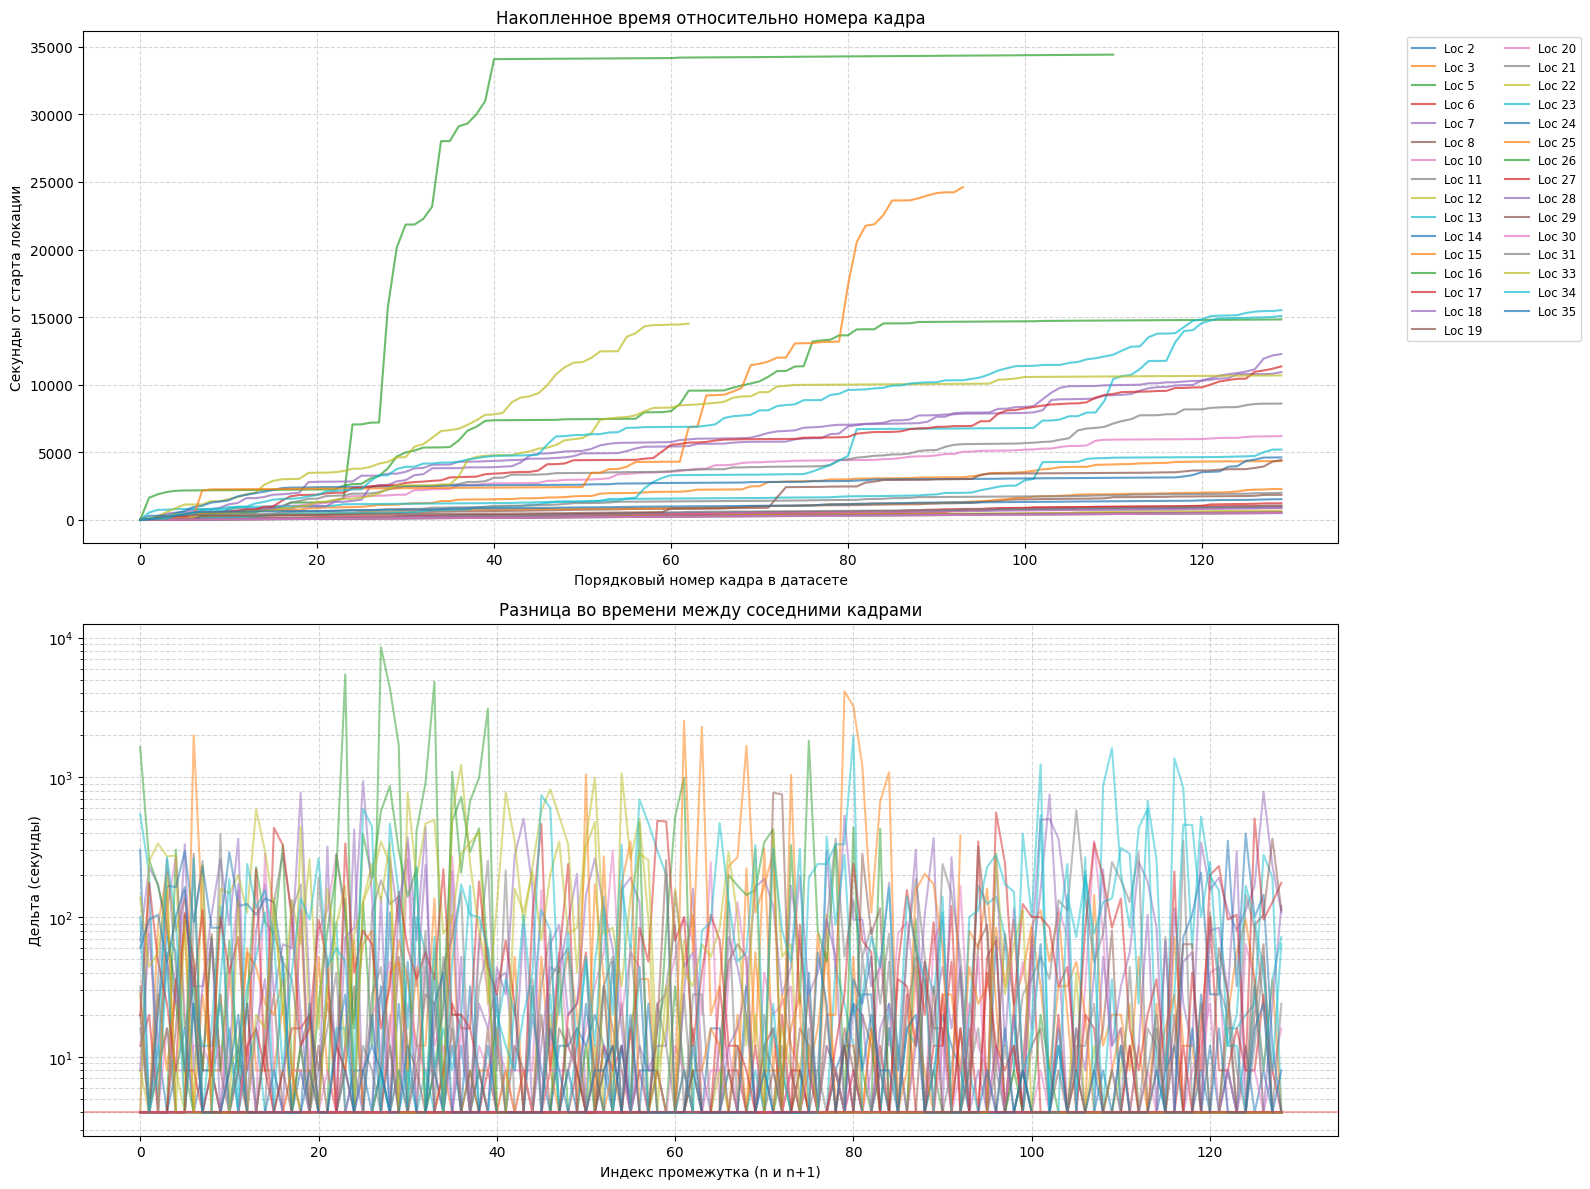

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


sorted_locs = sorted(data.keys(), key=lambda x: int(x))

plt.figure(figsize=(16, 12))


plt.subplot(2, 1, 1)
for loc in sorted_locs:
    ids = sorted(data[loc])
    first_id = ids[0]
    relative_times = [(i - first_id) / 25.0 for i in ids]
    
    plt.plot(range(len(relative_times)), relative_times, label=f'Loc {loc}', alpha=0.7)

plt.title("Накопленное время относительно номера кадра")
plt.xlabel("Порядковый номер кадра в датасете")
plt.ylabel("Секунды от старта локации")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)

plt.subplot(2, 1, 2)
for loc in sorted_locs:
    ids = sorted(data[loc])
    diffs = [(ids[i] - ids[i-1]) / 25.0 for i in range(1, len(ids))]
    
    plt.plot(range(len(diffs)), diffs, alpha=0.5)

plt.axhline(y=4, color='r', linestyle='-', alpha=0.3, label='Идеальный шаг (4с)')

plt.title("Разница во времени между соседними кадрами")
plt.xlabel("Индекс промежутка (n и n+1)")
plt.ylabel("Дельта (секунды)")
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

GROUPED_DIR = "grouped_images"

loc_folders = sorted([d for d in os.listdir(GROUPED_DIR) if os.path.isdir(os.path.join(GROUPED_DIR, d))], key=lambda x: int(x))

cols = 4
rows = (len(loc_folders) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

print(f"Вычисляем средние изображения из {len(loc_folders)} локаций...")

for i, loc in enumerate(loc_folders):
    loc_path = os.path.join(GROUPED_DIR, loc)
    img_names = [f for f in os.listdir(loc_path) if f.endswith('.jpg')]
    
    if not img_names:
        continue
        
    mean_img = None
    count = 0
    
    for fname in img_names:
        img = cv2.imread(os.path.join(loc_path, fname))
        if img is None: continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if mean_img is None:
            mean_img = np.zeros_like(img, dtype=np.float64)
            
        mean_img += img
        count += 1
    
    if count > 0:
        mean_img /= count
        mean_img = mean_img.astype(np.uint8)
        
        axes[i].imshow(mean_img)
        axes[i].set_title(f"Локация {loc}\n({count} кадров)")
    
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


GROUPED_DIR = "./grouped_images"
locs = sorted(map(int, os.listdir(GROUPED_DIR)))



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
import re


def get_loc_train_fmt(fname):
    # 0209-[LOC]_[ID].jpg
    return re.split(r'[-_.]', fname)[1]

def get_loc_test_fmt(fname):
     # [LOC]_[???].jpg
     return fname.split('_')[0]


def get_fnames_common_pool(root, loc, get_loc):
    return tuple(
        map(lambda x: f"{root}/{x}",
        filter(lambda x: loc == get_loc(x),
        os.listdir(root)
    )))


def mean_img(fnames):
    imgs_sum = None
    for fname in fnames:
            img: np.ndarray = cv2.imread(fname)  # type: ignore
            # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if imgs_sum is None:
                imgs_sum = np.zeros_like(img, dtype=np.float64)
            imgs_sum += img

    res = imgs_sum / len(fnames)  # type: ignore
    res = res.astype(np.uint8)
    return res

def var_img(fnames, mean=None):
    mean = mean or mean_img(fnames)
    imgs_acc = None
    for fname in fnames:
        img: np.ndarray = cv2.imread(fname)  # type: ignore
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if imgs_acc is None:
            imgs_acc = np.zeros_like(img, dtype=np.float64)
        imgs_acc += (img - mean)**2
    res = imgs_acc / len(fnames)  # type: ignore
    return res

def std_img(fnames, mean=None):
    return np.sqrt(var_img(fnames, mean))

def std_img_rgb(fnames, mean=None):
    std = std_img(fnames, mean)
    res = std / std.max() * 256
    res = res.astype(np.uint8)
    return res

In [5]:
TRN_LOC = set()
TRN_PTH = "./dl-lab-2-stuff-detection/yolo_dataset/yolo_dataset/train/images"
TST_LOC = set()
TST_PTH = "./dl-lab-2-stuff-detection/test_images/test_images"

for fname in tqdm(os.listdir(TRN_PTH), desc="TRN"):
    TRN_LOC.add(get_loc_train_fmt(fname))
TRN_LOC = frozenset(TRN_LOC)

for fname in tqdm(os.listdir(TST_PTH), desc="TST"):
    TST_LOC.add(get_loc_test_fmt(fname))
TST_LOC = frozenset(TST_LOC)

print(f"{TRN_LOC=}")
print(f"{TST_LOC=}")

TST: 100%|██████████| 4454/4454 [00:00<00:00, 594401.03it/s]

TRN_LOC=frozenset({'35', '21', '28', '17', '11', '12', '24', '3', '8', '30', '22', '34', '6', '26', '15', '20', '23', '27', '5', '7', '33', '13', '29', '10', '19', '2', '16', '18', '31', '14', '25'})
TST_LOC=frozenset({'21', '16.1', '35', '15.1', '3', '37', '8', '13.1', '14.1', '3.1', '19.1', '32', '1.1', '14', '10.1'})


In [6]:
OUT_DIR = "./mean_images"

for loc in tqdm(TRN_LOC, desc='TRN'):
    mean = mean_img(get_fnames_common_pool(TRN_PTH, loc, get_loc_train_fmt))
    out = f"{OUT_DIR}/train-{loc}.jpg"
    cv2.imwrite(out, mean)

for loc in tqdm(TST_LOC, desc='TST'):
    mean = mean_img(get_fnames_common_pool(TST_PTH, loc, get_loc_test_fmt))
    out = f"{OUT_DIR}/test-{loc}.jpg"
    cv2.imwrite(out, mean)

TST: 100%|██████████| 15/15 [00:30<00:00,  2.06s/it]


In [ ]:
MEAN_DIR = "./mean_images"
print({
    cv2.imread(f"{MEAN_DIR}/{fname}").shape  # type: ignore
    for fname in tqdm(os.listdir(MEAN_DIR))
})

100%|██████████| 46/46 [00:00<00:00, 223.13it/s]

{(720, 1280, 3)}


In [ ]:
# здесб должна была быть матрица средних разностей

MEAN_DIR = "./mean_images"



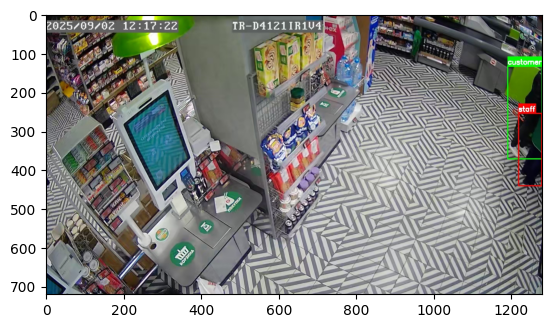

In [6]:
fname = fnames[12]
img = cv2.imread(f"{loc_path}/{fname}")
assert img is not None
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)